# 🎓 Predicting On-Time Graduation of Civil Engineering Students
## A Three-Model Machine Learning Approach

---

| Model | Features Used | Purpose |
|-------|---------------|---------|
| **Model 1** | SASE Scores + SHS GWA + SHS Strand | Pre-admission & SHS background profiling |
| **Model 2** | Critical Subject Grades + CGPA + Retake Behavior | In-program academic risk monitoring |
| **Model 3** | All of the above (combined) | Comprehensive risk profiling |

**Target Variable:** `GRADUATION_STATUS` — **1 = On-Time** (≤ 8 semesters / 4 years), **0 = Delayed**

**Grading Scale Note:** Philippine grading — **1.0 = Highest (Excellent)**, **3.0 = Lowest Passing**


## SECTION 1 — Import Libraries

In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

print('✅ All libraries imported!')

✅ All libraries imported!


## SECTION 2 — Load & Parse Dataset

In [5]:
# # ── Local path — update as needed ────────────────────────────
# file_path = r"C:/Users/User(Ooz)/Downloads/CE_datasets.csv"
# raw = pd.read_csv(file_path, header=None)
# print(f"\nRaw file shape: {raw.shape} (rows × cols)")

# ── Google Colab upload ───────────────────────────────────────
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
raw = pd.read_csv(file_path, header=None)

print(f'Raw shape: {raw.shape}')

Saving Ce_dataset_v2.csv to Ce_dataset_v2.csv
Raw shape: (230, 32)


In [8]:
# ── Parse multi-level header & semester-batch separator rows ──
sep_rows = set(raw[raw[0].astype(str).str.contains('Sem', na=False)].index.tolist())
skip_rows = {0, 1, 2} | sep_rows

COLUMN_NAMES = [
    'NAME','SASE_GS','SASE_MA','SASE_LA','SASE_SCI','SASE_AP',
    'SHS_SCHOOL','SHS_TRACK','SHS_GWA',
    'MAT060','MAT060_TAKEN','MAT070','MAT070_TAKEN','ENS161','ENS161_TAKEN',
    'CVE155','CVE155_TAKEN','CVE151','CVE151_TAKEN','CVE161','CVE161_TAKEN',
    'CVE195','CVE195_TAKEN','CVE196','CVE196_TAKEN','CVE111','CVE111_TAKEN',
    'CVE112','CVE112_TAKEN','CGPA','YEAR_ADMITTED','YEAR_GRADUATED'
]

BATCH_MAP = {}
for idx in sep_rows:
    BATCH_MAP[idx+1] = raw.iloc[idx, 0]
BATCH_BOUNDS = sorted(BATCH_MAP.keys())

def get_batch(idx):
    label = None
    for b in BATCH_BOUNDS:
        if idx >= b: label = BATCH_MAP[b]
    return label

student_rows = []
for i in range(len(raw)):
    if i in skip_rows: continue
    row = list(raw.iloc[i])
    name = str(row[0]).strip()
    if not name or name == 'nan': continue
    student_rows.append(row + [get_batch(i)])

df = pd.DataFrame(student_rows, columns=COLUMN_NAMES + ['GRADUATION_BATCH'])

# Remove trailing garbage rows (artifact from Excel — CGPA repeats as year)
df = df[~df['YEAR_ADMITTED'].astype(str).str.match(r'^\d\.\d+$', na=False)].copy()
df = df[df['YEAR_ADMITTED'].notna()].copy()
df = df[~df['YEAR_ADMITTED'].astype(str).str.strip().isin(['nan',''])].copy()
df = df.reset_index(drop=True)

print(f'✅ Parsed {len(df)} clean student records')
display(df[['NAME','SASE_GS','SHS_TRACK','SHS_GWA','MAT060','CGPA','YEAR_ADMITTED','YEAR_GRADUATED']].head(8))

✅ Parsed 161 clean student records


,NAME,SASE_GS,SHS_TRACK,SHS_GWA,MAT060,CGPA,YEAR_ADMITTED,YEAR_GRADUATED
0,"Ador, Janal M.",74,GAS,91-95,2.50,1.885,1st Sem 2018-2019,2nd Sem 2021-2022
1,"Casinillo, Ruben Jr.",71,STEM,96-100,1.75,1.898,1st Sem 2018-2019,2nd Sem 2021-2022
2,"Conjurado, Benchell",77,STEM,86-90,1.00,1.487,1st Sem 2018-2019,2nd Sem 2021-2022
3,"Daud, Norhanisah",90,STEM,91-95,1..75,1.654,1st Sem 2018-2019,2nd Sem 2021-2022
4,"Fabay, Jorden",89,STEM,91-95,1.25,1.704,1st Sem 2018-2019,2nd Sem 2021-2022
5,"Ibrahim, Abdulraffi C.",100,NaN,NaN,1.00,1.673,1st Sem 2018-2019,2nd Sem 2021-2022
6,"Jaber, Basim E.",81,STEM,86-90,2.00,1.821,1st Sem 2018-2019,2nd Sem 2021-2022
7,"Malawi, Imran B.",92,NaN,NaN,1.75,1.881,1st Sem 2018-2019,2nd Sem 2021-2022


## SECTION 3 — Data Cleaning & Feature Engineering

In [9]:
SASE_COLS  = ['SASE_GS', 'SASE_MA', 'SASE_LA', 'SASE_SCI', 'SASE_AP']
GRADE_COLS = ['MAT060','MAT070','ENS161','CVE155','CVE151',
              'CVE161','CVE195','CVE196','CVE111','CVE112']
TAKEN_COLS = [c + '_TAKEN' for c in GRADE_COLS]

# SASE → numeric
for c in SASE_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Subject grades → numeric (fix typos like '1..75', '1,75')
for c in GRADE_COLS:
    df[c] = (df[c].astype(str).str.strip()
               .str.replace(r'\.{2,}', '.', regex=True)
               .str.replace(',', '.', regex=False))
    df[c] = pd.to_numeric(df[c], errors='coerce')

for c in TAKEN_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['CGPA'] = (df['CGPA'].astype(str).str.strip()
               .str.replace('\xa0', '', regex=False)
               .str.replace(',', '.', regex=False))
df['CGPA'] = pd.to_numeric(df['CGPA'], errors='coerce')

# ── SHS GWA: convert range strings to numeric midpoints ───────
GWA_MAP = {
    '80-85': 82.5, '81-85': 83.0, '86-90': 88.0,
    '91-95': 93.0, '91-93': 92.0, '96-100': 98.0, '96-99': 97.5
}
df['SHS_GWA_NUM'] = df['SHS_GWA'].map(GWA_MAP)

# ── SHS Strand: one-hot encode ────────────────────────────────
strand_dummies = pd.get_dummies(df['SHS_TRACK'], prefix='STRAND', drop_first=False)
df = pd.concat([df, strand_dummies], axis=1)
STRAND_COLS = [c for c in df.columns if c.startswith('STRAND_')]

print('✅ Cleaning done. Strand columns:', STRAND_COLS)

✅ Cleaning done. Strand columns: ['STRAND_ABM', 'STRAND_GAS', 'STRAND_HUMSS', 'STRAND_ICT', 'STRAND_SPORTS', 'STRAND_STEM', 'STRAND_TVL']


In [10]:
# ── Target variable: GRADUATION_STATUS ───────────────────────
def semester_to_number(sem_str):
    s = str(sem_str).strip()
    if s in ['', 'nan', 'NaN']: return np.nan
    parts = s.split()
    half  = 0 if parts[0] == '1st' else 1
    year  = int(parts[2].split('-')[0])
    return year * 2 + half

df['ADM_NUM']     = df['YEAR_ADMITTED'].apply(semester_to_number)
df['GRAD_NUM']    = df['YEAR_GRADUATED'].apply(semester_to_number)
df['SEMS_TO_GRAD']= df['GRAD_NUM'] - df['ADM_NUM']

# On-Time: completed in ≤ 8 semesters (diff < 8)
df['GRADUATION_STATUS'] = np.where(
    df['SEMS_TO_GRAD'].isna(), np.nan,
    (df['SEMS_TO_GRAD'] < 8).astype(float)
)

# ── Derived struggle features (for Models 2 & 3) ──────────────
df['TOTAL_RETAKES'] = (df[TAKEN_COLS] - 1).clip(lower=0).sum(axis=1)
df['MAX_RETAKE']    = (df[TAKEN_COLS] - 1).clip(lower=0).max(axis=1)
df['SUBJECTS_TAKEN']= df[GRADE_COLS].notna().sum(axis=1)
df['AVG_GRADE']     = df[GRADE_COLS].mean(axis=1)
df['HARD_FAILS']    = (df[GRADE_COLS] >= 3.00).sum(axis=1)

df_labeled = df[df['GRADUATION_STATUS'].notna()].copy()
vc = df_labeled['GRADUATION_STATUS'].value_counts()
print(f'✅ Students with graduation status: {len(df_labeled)}')
print(f'   On-Time (1): {int(vc.get(1.0,0))}  |  Delayed (0): {int(vc.get(0.0,0))}')

✅ Students with graduation status: 161
   On-Time (1): 54  |  Delayed (0): 107


## SECTION 4 — Exploratory Data Analysis

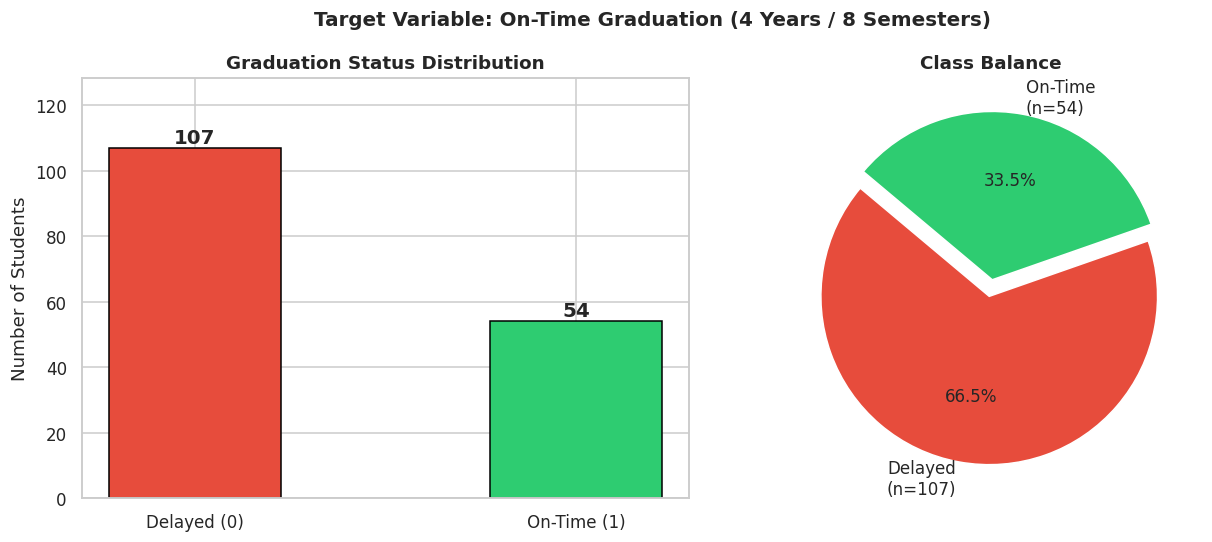

In [11]:
# ── 4A: Class distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df_labeled['GRADUATION_STATUS'].value_counts().sort_index()
clr = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(['Delayed (0)','On-Time (1)'], vc.values, color=clr, edgecolor='black', width=0.45)
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+1.5, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Graduation Status Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Students'); axes[0].set_ylim(0, max(vc.values)*1.2)
axes[1].pie(vc.values,
    labels=[f'Delayed\n(n={int(vc[0.0])})', f'On-Time\n(n={int(vc[1.0])})'],
    autopct='%1.1f%%', colors=clr, startangle=140, explode=(0.05,0.05))
axes[1].set_title('Class Balance', fontweight='bold')
plt.suptitle('Target Variable: On-Time Graduation (4 Years / 8 Semesters)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

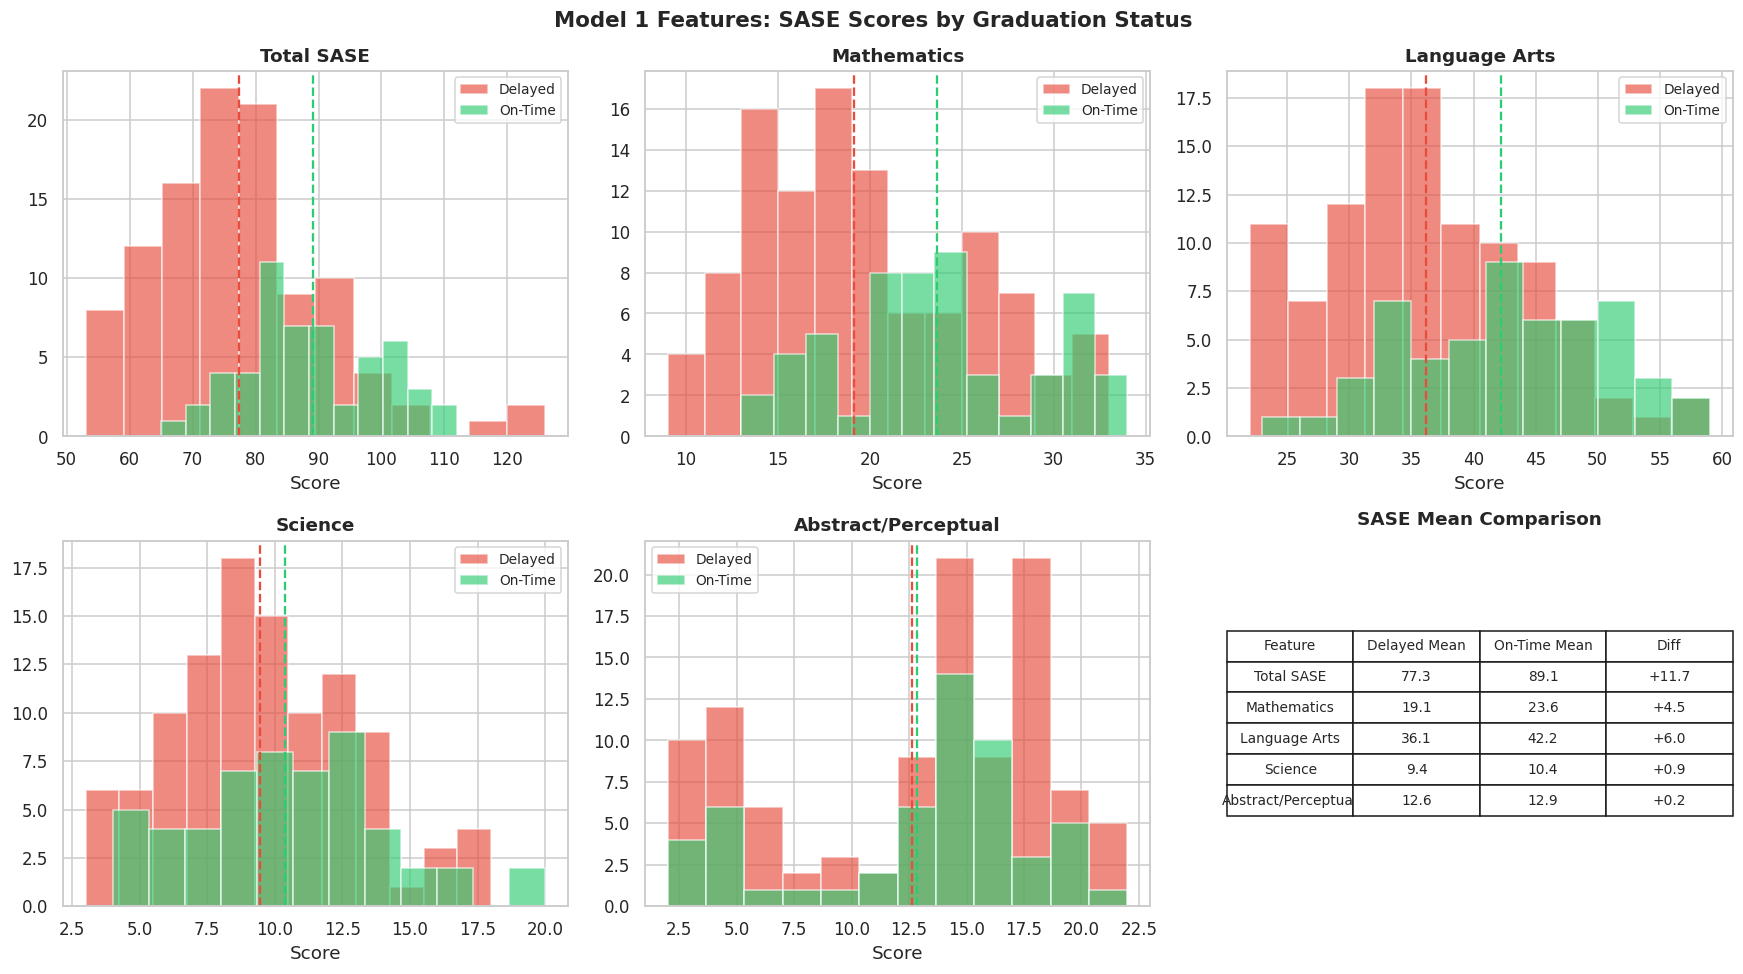

In [12]:
# ── 4B: SASE Score Distributions (Model 1 features) ──────────
sase_labels = {'SASE_GS':'Total SASE','SASE_MA':'Mathematics',
               'SASE_LA':'Language Arts','SASE_SCI':'Science','SASE_AP':'Abstract/Perceptual'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.flatten()
for idx, (col, label) in enumerate(sase_labels.items()):
    ax = axes[idx]
    for st, color, name in [(0,'#e74c3c','Delayed'),(1,'#2ecc71','On-Time')]:
        sub = df_labeled[df_labeled['GRADUATION_STATUS']==st][col].dropna()
        ax.hist(sub, bins=12, alpha=0.65, color=color, label=name, edgecolor='white')
        ax.axvline(sub.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Score'); ax.legend(fontsize=9)
axes[5].axis('off')
tbl_data = []
for col, label in sase_labels.items():
    m0 = df_labeled[df_labeled['GRADUATION_STATUS']==0][col].mean()
    m1 = df_labeled[df_labeled['GRADUATION_STATUS']==1][col].mean()
    tbl_data.append([label, f'{m0:.1f}', f'{m1:.1f}', f'{m1-m0:+.1f}'])
tbl = axes[5].table(cellText=tbl_data,
    colLabels=['Feature','Delayed Mean','On-Time Mean','Diff'], cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.6)
axes[5].set_title('SASE Mean Comparison', fontweight='bold', pad=10)
plt.suptitle('Model 1 Features: SASE Scores by Graduation Status', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

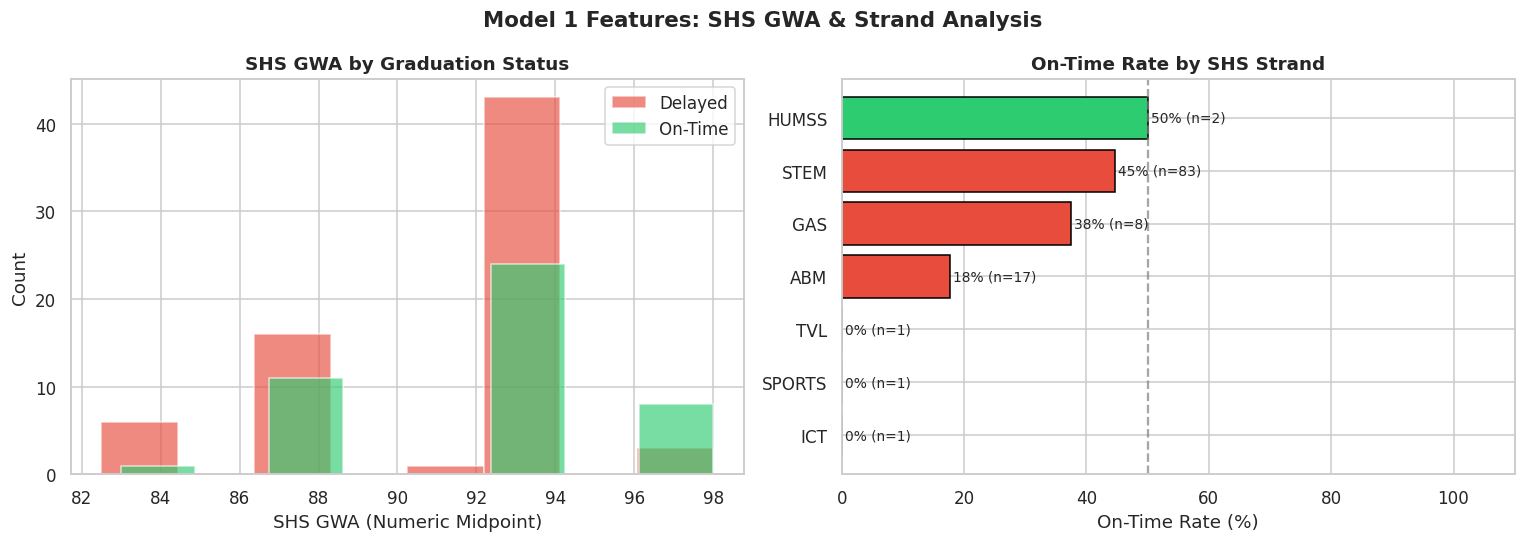

In [13]:
# ── 4C: SHS GWA & Strand (Model 1 features) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for st, color, name in [(0,'#e74c3c','Delayed'),(1,'#2ecc71','On-Time')]:
    sub = df_labeled[df_labeled['GRADUATION_STATUS']==st]['SHS_GWA_NUM'].dropna()
    axes[0].hist(sub, bins=8, alpha=0.65, color=color, label=name, edgecolor='white')
axes[0].set_xlabel('SHS GWA (Numeric Midpoint)'); axes[0].set_ylabel('Count')
axes[0].set_title('SHS GWA by Graduation Status', fontweight='bold'); axes[0].legend()

strand_counts = df_labeled.groupby('SHS_TRACK')['GRADUATION_STATUS'].agg(
    Total='count', OnTime=lambda x:(x==1).sum()).reset_index()
strand_counts['Rate'] = strand_counts['OnTime']/strand_counts['Total']*100
strand_counts = strand_counts.sort_values('Rate')
sc = ['#2ecc71' if r >= 50 else '#e74c3c' for r in strand_counts['Rate']]
axes[1].barh(strand_counts['SHS_TRACK'], strand_counts['Rate'], color=sc, edgecolor='black')
for i, (rate, tot) in enumerate(zip(strand_counts['Rate'], strand_counts['Total'])):
    axes[1].text(rate+0.5, i, f'{rate:.0f}% (n={tot})', va='center', fontsize=9)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('On-Time Rate (%)'); axes[1].set_title('On-Time Rate by SHS Strand', fontweight='bold')
axes[1].set_xlim(0, 110)
plt.suptitle('Model 1 Features: SHS GWA & Strand Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

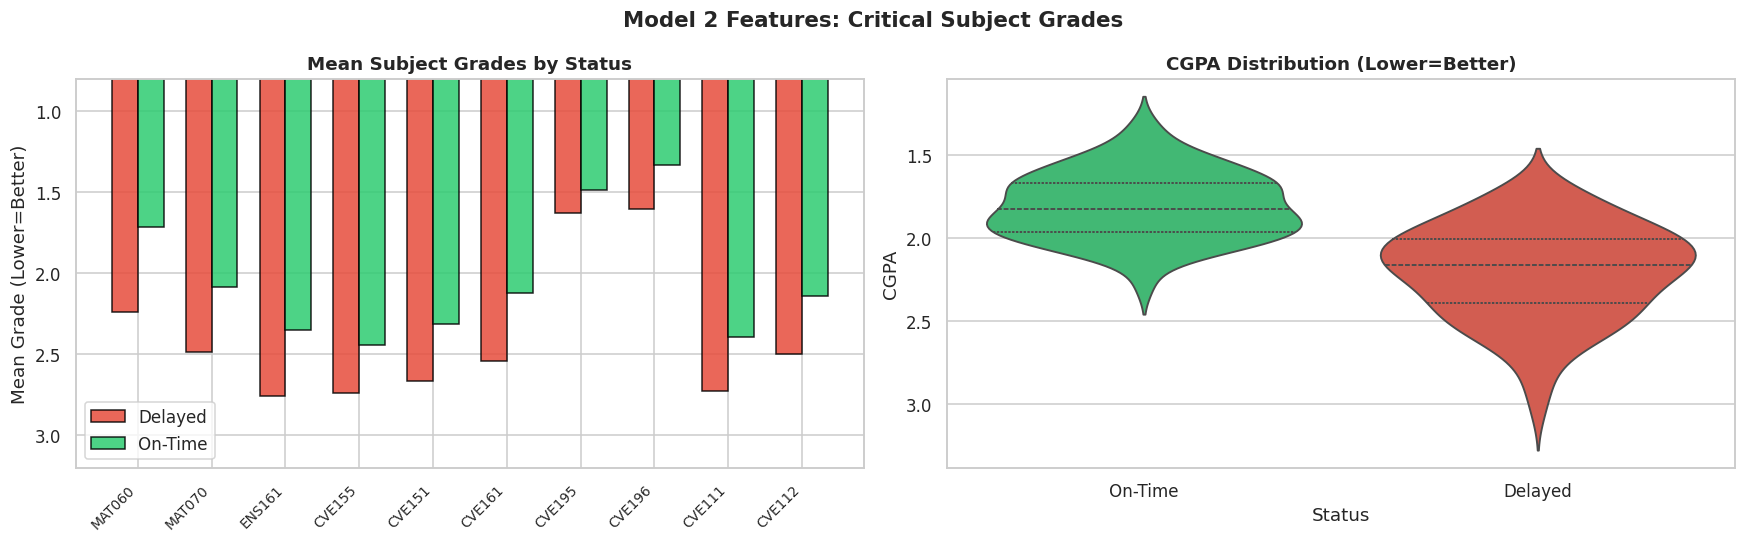

In [14]:
# ── 4D: Critical Subject Grades (Model 2 features) ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
means0 = df_labeled[df_labeled['GRADUATION_STATUS']==0][GRADE_COLS].mean()
means1 = df_labeled[df_labeled['GRADUATION_STATUS']==1][GRADE_COLS].mean()
x = np.arange(len(GRADE_COLS)); w = 0.35
axes[0].bar(x-w/2, means0, w, label='Delayed', color='#e74c3c', alpha=0.85, edgecolor='black')
axes[0].bar(x+w/2, means1, w, label='On-Time', color='#2ecc71', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(GRADE_COLS, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Mean Grade (Lower=Better)'); axes[0].set_title('Mean Subject Grades by Status', fontweight='bold')
axes[0].invert_yaxis(); axes[0].set_ylim(3.2, 0.8); axes[0].legend()

cgpa_data = df_labeled[['CGPA','GRADUATION_STATUS']].dropna().copy()
cgpa_data['Status'] = cgpa_data['GRADUATION_STATUS'].map({0:'Delayed',1:'On-Time'})
sns.violinplot(data=cgpa_data, x='Status', y='CGPA',
               palette={'Delayed':'#e74c3c','On-Time':'#2ecc71'}, ax=axes[1], inner='quartile')
axes[1].set_title('CGPA Distribution (Lower=Better)', fontweight='bold'); axes[1].invert_yaxis()
plt.suptitle('Model 2 Features: Critical Subject Grades', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## SECTION 5 — Feature Sets

In [15]:
# ── MODEL 1: SASE Scores + SHS GWA + SHS Strand ──────────────
FEATURES_1 = SASE_COLS + ['SHS_GWA_NUM'] + STRAND_COLS

# ── MODEL 2: Critical Subject Grades + CGPA + Retake Behavior ─
FEATURES_2 = GRADE_COLS + ['CGPA', 'TOTAL_RETAKES', 'MAX_RETAKE', 'AVG_GRADE', 'HARD_FAILS']

# ── MODEL 3: Combined (Model 1 + Model 2) ────────────────────
FEATURES_3 = FEATURES_1 + FEATURES_2

TARGET = 'GRADUATION_STATUS'

print('📋 FEATURE SETS')
print(f'  Model 1 ({len(FEATURES_1)} features): SASE + GWA + Strand')
print(f'  Model 2 ({len(FEATURES_2)} features): Subject Grades + CGPA + Retakes')
print(f'  Model 3 ({len(FEATURES_3)} features): Combined')

📋 FEATURE SETS
  Model 1 (13 features): SASE + GWA + Strand
  Model 2 (15 features): Subject Grades + CGPA + Retakes
  Model 3 (28 features): Combined


## SECTION 6 — Data Preparation Helper

In [16]:
def prepare_data(features, df_src, target=TARGET, test_size=0.2, seed=42):
    """Impute, scale, and split data for a given feature set."""
    sub = df_src.dropna(subset=[target]).copy()
    X = sub[features]
    y = sub[target]
    imp = SimpleImputer(strategy='median')
    scl = StandardScaler()
    X_imp = imp.fit_transform(X)
    X_scl = scl.fit_transform(X_imp)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scl, y, test_size=test_size, random_state=seed, stratify=y)
    return X_tr, X_te, y_tr, y_te, X_scl, y, imp, scl

def build_models():
    """Instantiate fresh set of three classifiers per system."""
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=42),

        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_split=5,
            min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
    }

def evaluate_models(models_dict, X_test, y_test, system_label):
    """Evaluate all models and collect metrics."""
    results = []
    print(f'\n{"="*60}\n  {system_label}\n{"="*60}')
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        print(f'\n  {name}:')
        print(classification_report(y_test, y_pred,
              target_names=['Delayed (0)','On-Time (1)'], zero_division=0))
        results.append({
            'Model':     name,
            'Accuracy':  round(accuracy_score(y_test, y_pred)*100, 2),
            'Precision': round(rep['weighted avg']['precision']*100, 2),
            'Recall':    round(rep['weighted avg']['recall']*100, 2),
            'F1-Score':  round(rep['weighted avg']['f1-score']*100, 2),
            'ROC-AUC':   round(roc_auc_score(y_test, y_prob)*100, 2),
            'y_pred': y_pred, 'y_prob': y_prob
        })
    return results

print('✅ Helper functions defined')

✅ Helper functions defined


## SECTION 7 — Train All Three Models

In [17]:
# ── Prepare data for each model ───────────────────────────────
X1_tr, X1_te, y1_tr, y1_te, X1_full, y1_full, imp1, scl1 = prepare_data(FEATURES_1, df_labeled)
X2_tr, X2_te, y2_tr, y2_te, X2_full, y2_full, imp2, scl2 = prepare_data(FEATURES_2, df_labeled)
X3_tr, X3_te, y3_tr, y3_te, X3_full, y3_full, imp3, scl3 = prepare_data(FEATURES_3, df_labeled)

# ── Train ─────────────────────────────────────────────────────
models_1 = build_models()
models_2 = build_models()
models_3 = build_models()

for name, m in models_1.items(): m.fit(X1_tr, y1_tr)
for name, m in models_2.items(): m.fit(X2_tr, y2_tr)
for name, m in models_3.items(): m.fit(X3_tr, y3_tr)

print('✅ Model 1 (SASE + GWA + Strand)         — all 3 algorithms trained')
print('✅ Model 2 (Critical Subject Grades)      — all 3 algorithms trained')
print('✅ Model 3 (Combined)                     — all 3 algorithms trained')

✅ Model 1 (SASE + GWA + Strand)         — all 3 algorithms trained
✅ Model 2 (Critical Subject Grades)      — all 3 algorithms trained
✅ Model 3 (Combined)                     — all 3 algorithms trained


## SECTION 8 — Model Evaluation

In [18]:
results_1 = evaluate_models(models_1, X1_te, y1_te, 'MODEL 1 — SASE + GWA + Strand')
results_2 = evaluate_models(models_2, X2_te, y2_te, 'MODEL 2 — Critical Subject Grades')
results_3 = evaluate_models(models_3, X3_te, y3_te, 'MODEL 3 — Combined (All Features)')


  MODEL 1 — SASE + GWA + Strand

  Logistic Regression:
              precision    recall  f1-score   support

 Delayed (0)       0.89      0.73      0.80        22
 On-Time (1)       0.60      0.82      0.69        11

    accuracy                           0.76        33
   macro avg       0.74      0.77      0.75        33
weighted avg       0.79      0.76      0.76        33


  Random Forest:
              precision    recall  f1-score   support

 Delayed (0)       0.82      0.82      0.82        22
 On-Time (1)       0.64      0.64      0.64        11

    accuracy                           0.76        33
   macro avg       0.73      0.73      0.73        33
weighted avg       0.76      0.76      0.76        33


  MODEL 2 — Critical Subject Grades

  Logistic Regression:
              precision    recall  f1-score   support

 Delayed (0)       0.87      0.91      0.89        22
 On-Time (1)       0.80      0.73      0.76        11

    accuracy                           0.85   

In [19]:
# ── Performance summary tables ────────────────────────────────
metric_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df1_res = pd.DataFrame(results_1)[metric_cols].set_index('Model')
df2_res = pd.DataFrame(results_2)[metric_cols].set_index('Model')
df3_res = pd.DataFrame(results_3)[metric_cols].set_index('Model')

print('📊 MODEL 1 — SASE + GWA + Strand  (all values in %)')
print('─'*60); display(df1_res)

print('\n📊 MODEL 2 — Critical Subject Grades  (all values in %)')
print('─'*60); display(df2_res)

print('\n📊 MODEL 3 — Combined  (all values in %)')
print('─'*60); display(df3_res)

print(f'\n🏆 Best Model 1: {df1_res["F1-Score"].idxmax()} — F1={df1_res["F1-Score"].max()}%')
print(f'🏆 Best Model 2: {df2_res["F1-Score"].idxmax()} — F1={df2_res["F1-Score"].max()}%')
print(f'🏆 Best Model 3: {df3_res["F1-Score"].idxmax()} — F1={df3_res["F1-Score"].max()}%')

📊 MODEL 1 — SASE + GWA + Strand  (all values in %)
────────────────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,75.76,79.26,75.76,76.41,81.40
Random Forest,75.76,75.76,75.76,75.76,83.88



📊 MODEL 2 — Critical Subject Grades  (all values in %)
────────────────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,84.85,84.64,84.85,84.66,92.98
Random Forest,87.88,87.96,87.88,87.54,91.74



📊 MODEL 3 — Combined  (all values in %)
────────────────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,84.85,85.32,84.85,85.00,90.91
Random Forest,84.85,84.64,84.85,84.66,92.98



🏆 Best Model 1: Logistic Regression — F1=76.41%
🏆 Best Model 2: Random Forest — F1=87.54%
🏆 Best Model 3: Logistic Regression — F1=85.0%


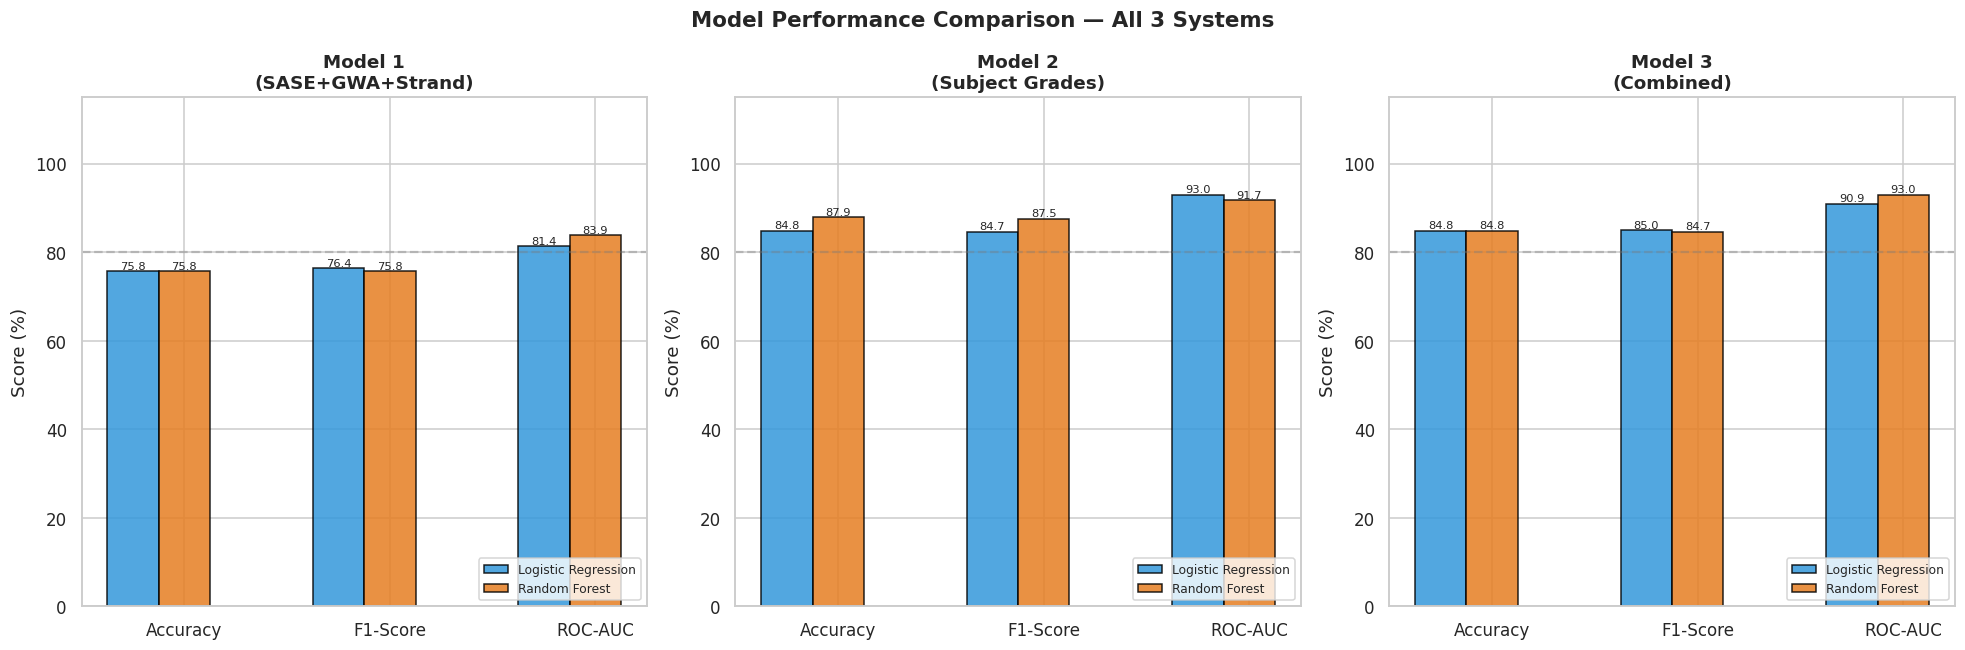

In [20]:
# ── Performance bar chart comparison ─────────────────────────
m_colors = ['#3498db', '#e67e22', '#9b59b6']
metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sys_labels = ['Model 1\n(SASE+GWA+Strand)', 'Model 2\n(Subject Grades)', 'Model 3\n(Combined)']

for ax, results, title in zip(axes, [results_1, results_2, results_3], sys_labels):
    x = np.arange(len(metrics)); w = 0.25
    for i, (res, color) in enumerate(zip(results, m_colors)):
        vals = [res[m] for m in metrics]
        bars = ax.bar(x + i*w, vals, w, label=res['Model'], color=color, alpha=0.85, edgecolor='black')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.1f}', ha='center', fontsize=7.5)
    ax.set_xticks(x+w); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 115); ax.set_ylabel('Score (%)'); ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8); ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Model Performance Comparison — All 3 Systems', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

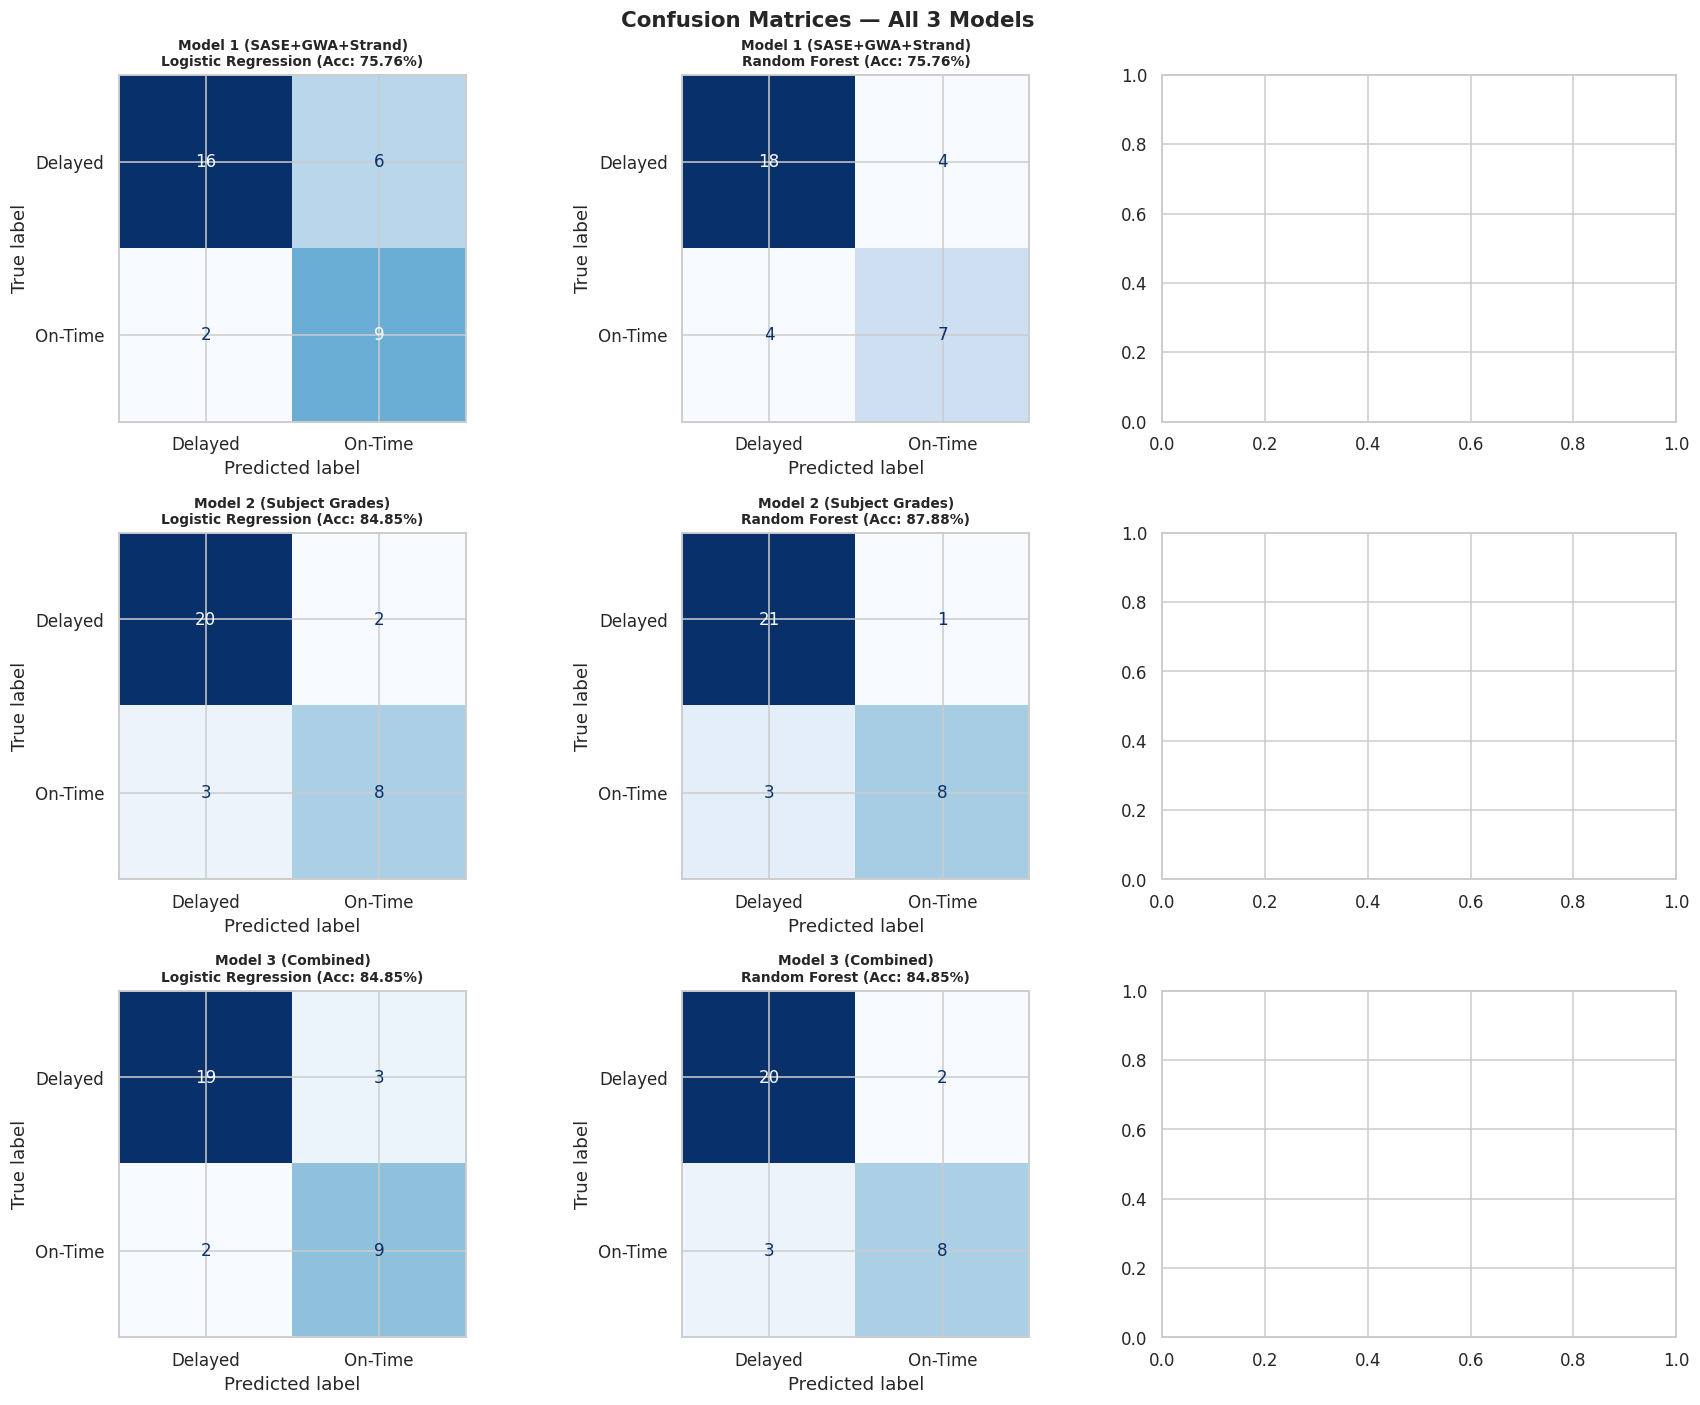

In [21]:
# ── Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for row_idx, (results, y_test, system) in enumerate([
    (results_1, y1_te, 'Model 1 (SASE+GWA+Strand)'),
    (results_2, y2_te, 'Model 2 (Subject Grades)'),
    (results_3, y3_te, 'Model 3 (Combined)'),
]):
    for col_idx, res in enumerate(results):
        ax = axes[row_idx][col_idx]
        cm = confusion_matrix(y_test, res['y_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Delayed','On-Time'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f"{system}\n{res['Model']} (Acc: {res['Accuracy']}%)",
                     fontsize=9, fontweight='bold')
plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

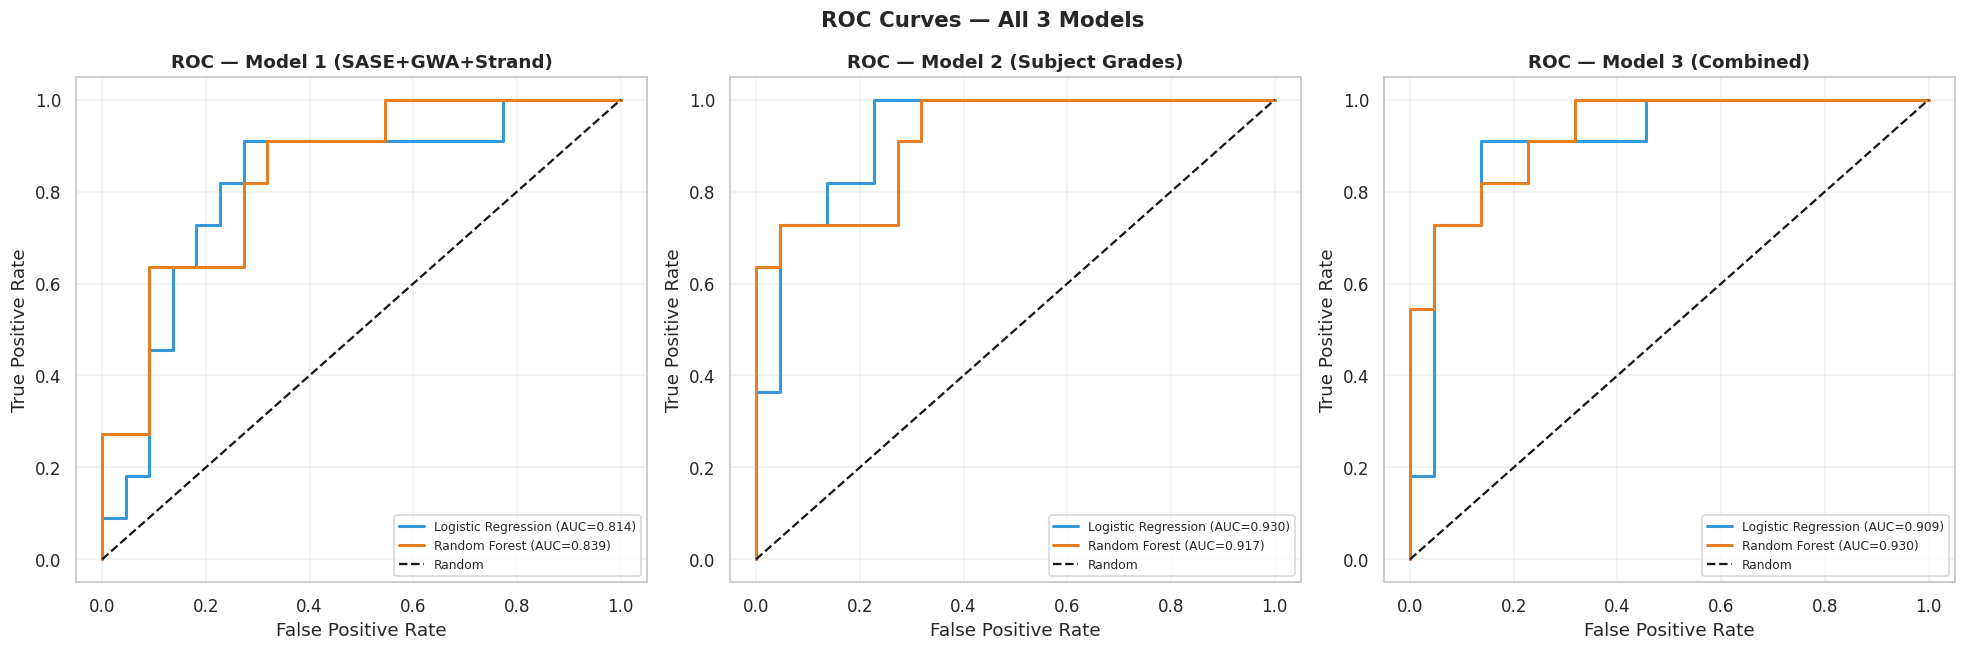

In [22]:
# ── ROC Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, results, y_test, title in [
    (axes[0], results_1, y1_te, 'Model 1 (SASE+GWA+Strand)'),
    (axes[1], results_2, y2_te, 'Model 2 (Subject Grades)'),
    (axes[2], results_3, y3_te, 'Model 3 (Combined)'),
]:
    for res, color in zip(results, m_colors):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{res['Model']} (AUC={res['ROC-AUC']/100:.3f})")
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {title}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves — All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

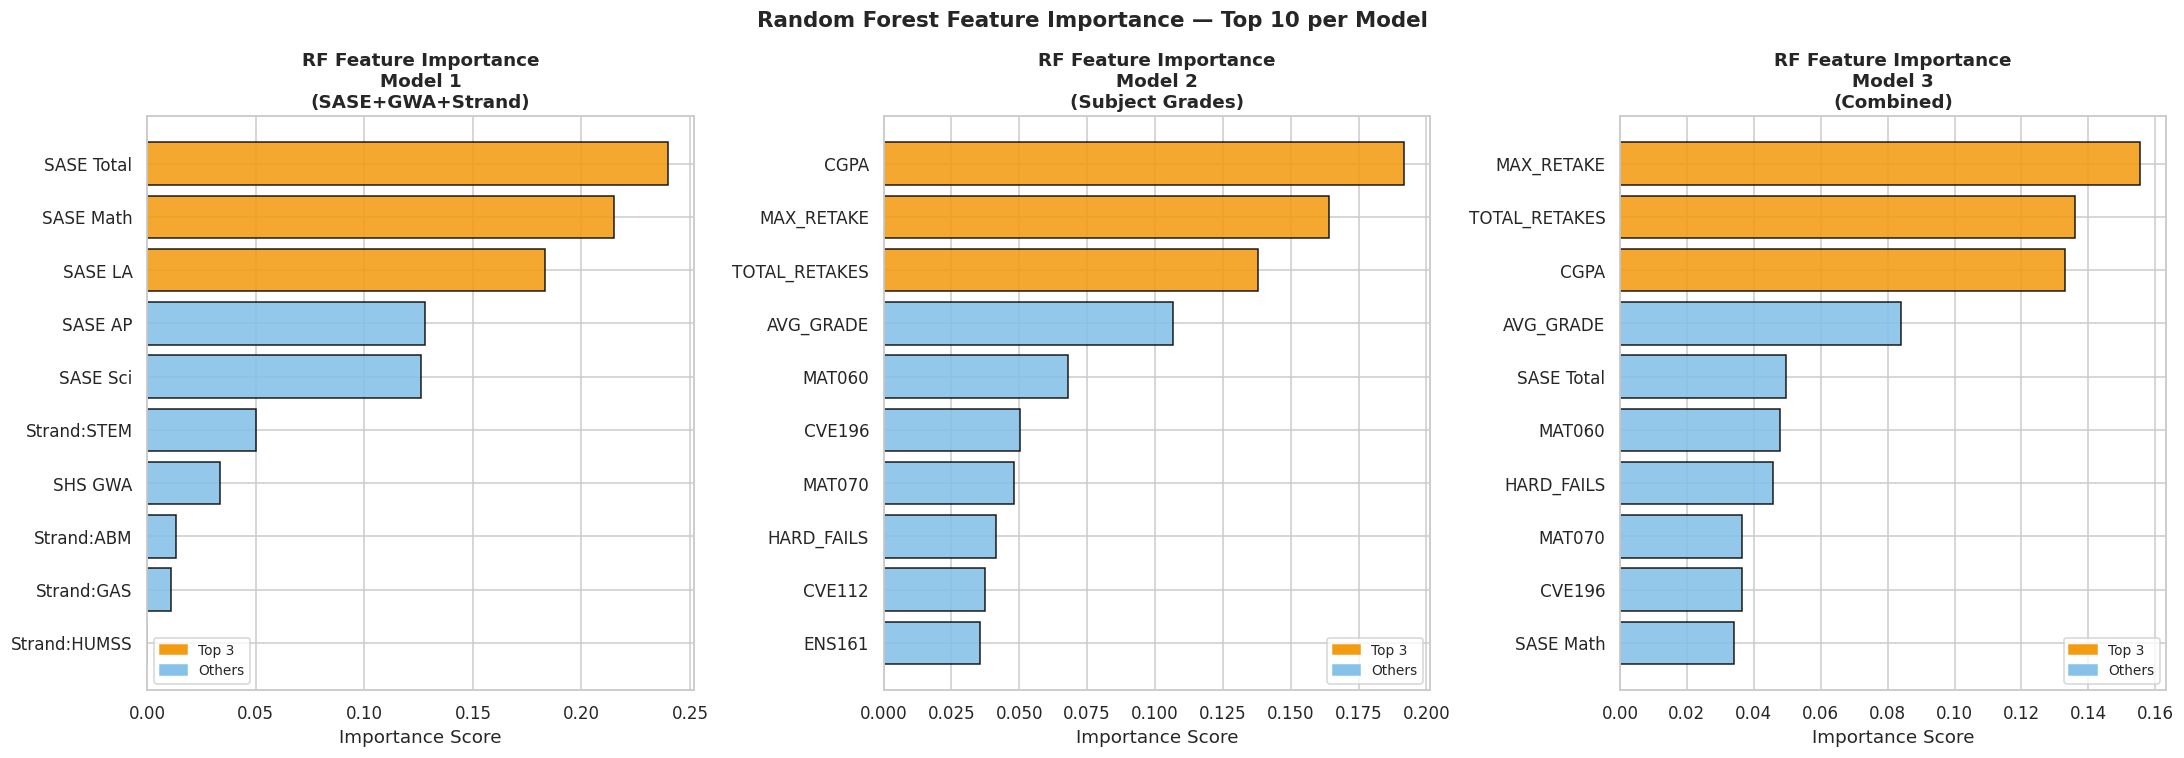

In [23]:
# ── Feature Importance (Random Forest) ───────────────────────
FEAT_LABELS = {
    'SASE_GS':'SASE Total','SASE_MA':'SASE Math','SASE_LA':'SASE LA',
    'SASE_SCI':'SASE Sci','SASE_AP':'SASE AP','SHS_GWA_NUM':'SHS GWA',
    'STRAND_STEM':'Strand:STEM','STRAND_ABM':'Strand:ABM','STRAND_GAS':'Strand:GAS',
    'STRAND_HUMSS':'Strand:HUMSS','STRAND_TVL':'Strand:TVL',
    'STRAND_ICT':'Strand:ICT','STRAND_SPORTS':'Strand:SPORTS',
}
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, models_dict, features, title in [
    (axes[0], models_1, FEATURES_1, 'Model 1\n(SASE+GWA+Strand)'),
    (axes[1], models_2, FEATURES_2, 'Model 2\n(Subject Grades)'),
    (axes[2], models_3, FEATURES_3, 'Model 3\n(Combined)'),
]:
    rf = models_dict['Random Forest']
    fi_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
    fi_df = fi_df.sort_values('Importance').tail(10)
    top3 = fi_df.nlargest(3,'Importance')['Feature'].values
    colors = ['#f39c12' if f in top3 else '#85c1e9' for f in fi_df['Feature']]
    fi_df['Label'] = fi_df['Feature'].apply(lambda x: FEAT_LABELS.get(x, x))
    ax.barh(fi_df['Label'], fi_df['Importance'], color=colors, edgecolor='black', alpha=0.88)
    ax.set_xlabel('Importance Score'); ax.set_title(f'RF Feature Importance\n{title}', fontweight='bold')
    gold = mpatches.Patch(color='#f39c12', label='Top 3')
    blue = mpatches.Patch(color='#85c1e9', label='Others')
    ax.legend(handles=[gold, blue], fontsize=9)
plt.suptitle('Random Forest Feature Importance — Top 10 per Model', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [24]:
# ── 5-Fold Stratified Cross-Validation ───────────────────────
print('📊 5-Fold Stratified Cross-Validation (F1 Weighted)\n' + '='*60)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for sys_label, models_dict, X_full, y_full in [
    ('Model 1 (SASE+GWA+Strand)',   models_1, X1_full, y1_full),
    ('Model 2 (Subject Grades)',    models_2, X2_full, y2_full),
    ('Model 3 (Combined)',          models_3, X3_full, y3_full),
]:
    print(f'\n  {sys_label}:')
    for name, model in models_dict.items():
        scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='f1_weighted')
        print(f'    {name:<25}: F1={scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%'
              f'  | Folds: {[round(s*100,1) for s in scores]}')

📊 5-Fold Stratified Cross-Validation (F1 Weighted)

  Model 1 (SASE+GWA+Strand):
    Logistic Regression      : F1=72.97% ± 7.25%  | Folds: [np.float64(76.2), np.float64(63.4), np.float64(75.4), np.float64(66.4), np.float64(83.5)]
    Random Forest            : F1=69.78% ± 7.04%  | Folds: [np.float64(78.5), np.float64(69.3), np.float64(71.5), np.float64(72.5), np.float64(57.1)]

  Model 2 (Subject Grades):
    Logistic Regression      : F1=82.89% ± 5.68%  | Folds: [np.float64(88.2), np.float64(90.5), np.float64(75.4), np.float64(81.6), np.float64(78.8)]
    Random Forest            : F1=85.72% ± 4.29%  | Folds: [np.float64(91.0), np.float64(90.5), np.float64(81.2), np.float64(81.2), np.float64(84.6)]

  Model 3 (Combined):
    Logistic Regression      : F1=81.63% ± 7.70%  | Folds: [np.float64(88.1), np.float64(90.5), np.float64(72.5), np.float64(72.5), np.float64(84.6)]
    Random Forest            : F1=84.49% ± 4.01%  | Folds: [np.float64(85.0), np.float64(90.5), np.float64(84.5), np.

## SECTION 9 — Prediction Functions

In [25]:


GWA_MAP = {'80-85':82.5,'81-85':83.0,'86-90':88.0,'91-95':93.0,'91-93':92.0,'96-100':98.0,'96-99':97.5}

def predict_model1(sase_gs, sase_ma, sase_la, sase_sci, sase_ap,
                   shs_gwa_range='91-95', shs_strand='STEM'):
    """
    MODEL 1: SASE Scores + SHS GWA + Strand prediction.
    shs_gwa_range: one of '80-85','81-85','86-90','91-95','91-93','96-100','96-99'
    shs_strand   : one of 'STEM','ABM','GAS','HUMSS','TVL','ICT','SPORTS'
    """
    row = {'SASE_GS':sase_gs,'SASE_MA':sase_ma,'SASE_LA':sase_la,
           'SASE_SCI':sase_sci,'SASE_AP':sase_ap,
           'SHS_GWA_NUM': GWA_MAP.get(shs_gwa_range, 88.0)}
    for sc in STRAND_COLS:
        strand_name = sc.replace('STRAND_','')
        row[sc] = 1 if strand_name == shs_strand else 0
    inp = pd.DataFrame([{f: row.get(f, 0) for f in FEATURES_1}])
    inp_s = scl1.transform(imp1.transform(inp))
    out = {}
    for name, model in models_1.items():
        pred = model.predict(inp_s)[0]
        prob = model.predict_proba(inp_s)[0]
        out[name] = {'label':'On-Time' if pred==1 else 'Delayed',
                     'p_ontime':round(prob[1]*100,1), 'p_delayed':round(prob[0]*100,1)}
    return out


def predict_model2(mat060=None, mat070=None, ens161=None, cve155=None, cve151=None,
                   cve161=None, cve195=None, cve196=None, cve111=None, cve112=None,
                   cgpa=None, total_retakes=0, max_retake=0, avg_grade=None, hard_fails=0):
    """
    MODEL 2: Critical subject grades prediction.
    Pass None for subjects not yet taken.
    Philippine grading: 1.0 = best, 3.0 = lowest passing.
    """
    def n(v): return float('nan') if v is None else v
    row = {'MAT060':n(mat060),'MAT070':n(mat070),'ENS161':n(ens161),'CVE155':n(cve155),
           'CVE151':n(cve151),'CVE161':n(cve161),'CVE195':n(cve195),'CVE196':n(cve196),
           'CVE111':n(cve111),'CVE112':n(cve112),'CGPA':n(cgpa),
           'TOTAL_RETAKES':total_retakes,'MAX_RETAKE':max_retake,
           'AVG_GRADE':n(avg_grade),'HARD_FAILS':hard_fails}
    inp = pd.DataFrame([{f: row.get(f, float('nan')) for f in FEATURES_2}])
    inp_s = scl2.transform(imp2.transform(inp))
    out = {}
    for name, model in models_2.items():
        pred = model.predict(inp_s)[0]
        prob = model.predict_proba(inp_s)[0]
        out[name] = {'label':'On-Time' if pred==1 else 'Delayed',
                     'p_ontime':round(prob[1]*100,1), 'p_delayed':round(prob[0]*100,1)}
    return out


def predict_model3(sase_gs, sase_ma, sase_la, sase_sci, sase_ap,
                   shs_gwa_range='91-95', shs_strand='STEM',
                   mat060=None, mat070=None, ens161=None, cve155=None, cve151=None,
                   cve161=None, cve195=None, cve196=None, cve111=None, cve112=None,
                   cgpa=None, total_retakes=0, max_retake=0, avg_grade=None, hard_fails=0):
    """MODEL 3: Combined full-profile prediction."""
    def n(v): return float('nan') if v is None else v
    row = {'SASE_GS':sase_gs,'SASE_MA':sase_ma,'SASE_LA':sase_la,
           'SASE_SCI':sase_sci,'SASE_AP':sase_ap,
           'SHS_GWA_NUM': GWA_MAP.get(shs_gwa_range, 88.0),
           'MAT060':n(mat060),'MAT070':n(mat070),'ENS161':n(ens161),'CVE155':n(cve155),
           'CVE151':n(cve151),'CVE161':n(cve161),'CVE195':n(cve195),'CVE196':n(cve196),
           'CVE111':n(cve111),'CVE112':n(cve112),'CGPA':n(cgpa),
           'TOTAL_RETAKES':total_retakes,'MAX_RETAKE':max_retake,
           'AVG_GRADE':n(avg_grade),'HARD_FAILS':hard_fails}
    for sc in STRAND_COLS:
        strand_name = sc.replace('STRAND_','')
        row[sc] = 1 if strand_name == shs_strand else 0
    inp = pd.DataFrame([{f: row.get(f, float('nan')) for f in FEATURES_3}])
    inp_s = scl3.transform(imp3.transform(inp))
    out = {}
    for name, model in models_3.items():
        pred = model.predict(inp_s)[0]
        prob = model.predict_proba(inp_s)[0]
        out[name] = {'label':'On-Time' if pred==1 else 'Delayed',
                     'p_ontime':round(prob[1]*100,1), 'p_delayed':round(prob[0]*100,1)}
    return out


def risk_label(rf_prob_ontime):
    if rf_prob_ontime >= 70:  return '🟢 LOW RISK — Likely to graduate on time.'
    elif rf_prob_ontime >= 45: return '🟡 MODERATE RISK — Monitor closely, provide support.'
    else:                     return '🔴 HIGH RISK — Recommend immediate academic advising.'


def print_prediction(model_results, model_name):
    print(f'\n🎓 {model_name} PREDICTION')
    print('='*55)
    print(f'  {"Algorithm":<25} {"Prediction":<15} {"P(On-Time)":<12} P(Delayed)')
    print('  ' + '-'*55)
    for name, v in model_results.items():
        icon = '🟢' if v['label']=='On-Time' else '🔴'
        print(f'  {name:<25} {icon} {v["label"]:<13} {v["p_ontime"]}%        {v["p_delayed"]}%')
    rf_prob = model_results['Random Forest']['p_ontime']
    print(f'\n  📌 Risk Assessment (RF): {risk_label(rf_prob)}')

print('✅ Prediction functions defined')

✅ Prediction functions defined


In [26]:
from sklearn.utils.parallel import Parallel, delayed

# ══════════════════════════════════════════════════════════════
# 📝 SAMPLE PREDICTION — MODIFY VALUES BELOW
# ══════════════════════════════════════════════════════════════

# ── MODEL 1: SASE + GWA + Strand ─────────────────────────────
r1 = predict_model1(
    sase_gs=80, sase_ma=20, sase_la=35, sase_sci=10, sase_ap=15,
    shs_gwa_range='91-95',
    shs_strand='STEM'         # STEM, ABM, GAS, HUMSS, TVL, ICT, SPORTS
)
print_prediction(r1, 'MODEL 1 (SASE + GWA + Strand)')

# ── MODEL 2: Critical Subject Grades ─────────────────────────
r2 = predict_model2(
    mat060=2.25, mat070=2.50, ens161=2.75,
    cve151=3.00, cve155=2.50, cve161=2.25,
    cve195=None, cve196=None, cve111=None, cve112=None,
    cgpa=2.40, total_retakes=2, max_retake=1, avg_grade=2.54, hard_fails=1
)
print_prediction(r2, 'MODEL 2 (Subject Grades)')

# ── MODEL 3: Combined ─────────────────────────────────────────
r3 = predict_model3(
    sase_gs=80, sase_ma=20, sase_la=35, sase_sci=10, sase_ap=15,
    shs_gwa_range='91-95', shs_strand='STEM',
    mat060=2.25, mat070=2.50, ens161=2.75,
    cve151=3.00, cve155=2.50, cve161=2.25,
    cgpa=2.40, total_retakes=2, max_retake=1, avg_grade=2.54, hard_fails=1
)
print_prediction(r3, 'MODEL 3 (Combined)')


🎓 MODEL 1 (SASE + GWA + Strand) PREDICTION
  Algorithm                 Prediction      P(On-Time)   P(Delayed)
  -------------------------------------------------------
  Logistic Regression       🔴 Delayed       46.4%        53.6%
  Random Forest             🔴 Delayed       31.6%        68.4%

  📌 Risk Assessment (RF): 🔴 HIGH RISK — Recommend immediate academic advising.

🎓 MODEL 2 (Subject Grades) PREDICTION
  Algorithm                 Prediction      P(On-Time)   P(Delayed)
  -------------------------------------------------------
  Logistic Regression       🔴 Delayed       2.7%        97.3%
  Random Forest             🔴 Delayed       1.9%        98.1%

  📌 Risk Assessment (RF): 🔴 HIGH RISK — Recommend immediate academic advising.

🎓 MODEL 3 (Combined) PREDICTION
  Algorithm                 Prediction      P(On-Time)   P(Delayed)
  -------------------------------------------------------
  Logistic Regression       🔴 Delayed       3.6%        96.4%
  Random Forest             🔴 Dela

In [28]:
# # @title
# import joblib
# import os
# import shutil
# from google.colab import files

# # ── Create model directory ─────────────────────────────────────
# os.makedirs("model", exist_ok=True)

# # ── Model 1: Pre-Admission (SASE + GWA + Strand) ──────────────
# joblib.dump(models_1["Random Forest"],       "model/model_1_rf.pkl")
# joblib.dump(models_1["Logistic Regression"], "model/model_1_lr.pkl")
# joblib.dump(imp1, "model/imputer_1.pkl")
# joblib.dump(scl1, "model/scaler_1.pkl")

# # ── Model 2: In-Program (Grades + CGPA + Retakes) ─────────────
# joblib.dump(models_2["Random Forest"],       "model/model_2_rf.pkl")
# joblib.dump(models_2["Logistic Regression"], "model/model_2_lr.pkl")
# joblib.dump(imp2, "model/imputer_2.pkl")
# joblib.dump(scl2, "model/scaler_2.pkl")

# # ── Model 3: Combined (All Features) ──────────────────────────
# joblib.dump(models_3["Random Forest"],       "model/model_3_rf.pkl")
# joblib.dump(models_3["Logistic Regression"], "model/model_3_lr.pkl")
# joblib.dump(imp3, "model/imputer_3.pkl")
# joblib.dump(scl3, "model/scaler_3.pkl")

# print("✅ 12 files saved:")
# for f in sorted(os.listdir("model")):
#     size = os.path.getsize(f"model/{f}") / 1024
#     print(f"   {f:<30} {size:>8.1f} KB")

# # ── Zip and download ───────────────────────────────────────────
# shutil.make_archive("model", "zip", ".", "model")
# print("\n📦 Downloading model.zip ...")
# files.download("model.zip")

✅ 12 files saved:
   imputer_1.pkl                       1.0 KB
   imputer_2.pkl                       1.0 KB
   imputer_3.pkl                       1.2 KB
   model_1_lr.pkl                      0.9 KB
   model_1_rf.pkl                    962.7 KB
   model_2_lr.pkl                      1.0 KB
   model_2_rf.pkl                    761.4 KB
   model_3_lr.pkl                      1.0 KB
   model_3_rf.pkl                    736.4 KB
   scaler_1.pkl                        0.9 KB
   scaler_2.pkl                        0.9 KB
   scaler_3.pkl                        1.3 KB

📦 Downloading model.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>